In [2]:
path = '/workspace/diploma'

In [10]:
import sys
import sqlite3
import pandas as pd
import re
import torch
import glob
import numpy as np
import json
import os

sys.path.append(os.path.abspath(path+'/results'))
from utils import evaluate_cf, plot_attack_comparison, plot_size_comparison

sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import load_documents, annotations_from_jsonl

# metrics

# load data

In [11]:
data_root = os.path.join(path, 'eraserbenchmark-master', 'data', 'movies')
movies_docs = load_documents(data_root)
movies = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))

In [12]:
def collect_df(model, path, movies, movies_docs):
    """
    Collect results for all prompt-engineering variants (including combined ones)
    and store each variant as its own column.
    """

    # Initialize main DataFrame with test-level info
    resDf = pd.DataFrame({
        'texts': [' '.join([' '.join(sentence) for sentence in movies_docs[instance.annotation_id]]) for instance in movies],
        'evidence_ranges': [[(ev.start_token, ev.end_token) for ev in next(iter(instance.evidences))] for instance in movies],
    })

    # Load CREST rationales from saved file
    crest_data_path = os.path.join(path, "results/crest/processed_movies_rationales.csv")
    crest_df = pd.read_csv(crest_data_path)
    resDf['crest_rationales'] = crest_df['word_rationales'].apply(lambda x: [int(i) for i in eval(x)]).tolist()

    base_dir = os.path.join(path, "introspections/results/analysis")
    os.chdir(base_dir)

    sqlite_files = glob.glob(f'analysis_m-{model}_y-none_d-imdb_p-test_t-counterfactual_*.sqlite')

    for file in sqlite_files:
        # Extract everything after c- and before _s-
        variant = file.split("c-")[-1].split("_s-")[0].strip('-')
        if variant == "" or variant == "_":
            variant = "baseline"

        # Normalize spacing and dashes in case of multiple prompt flags
        variant = variant.replace(' ', '-').strip()

        conn = sqlite3.connect(file)
        cursor = conn.cursor()
        cursor.execute("SELECT debug, explain, correct, faithful FROM Counterfactual;")
        df = pd.DataFrame(cursor.fetchall(), columns=['texts', 'selfexp', 'correct', 'faithful'])
        conn.close()

        # Add this variant as its own column
        resDf[variant] = df.apply(
            lambda row: {
                'selfexp': row['selfexp'],
                'correct': row['correct'],
                'faithful': row['faithful']
            },
            axis=1
        )

    # Load attack results
    os.chdir(path)
    csv_files = glob.glob(os.path.join("attacks/movie_attacks", f"{model}*"))
    for file in csv_files:
        df = pd.read_csv(file)
        attack_name = file.split('_')[-1].replace(".csv", "")
        resDf[attack_name] = df.apply(
            lambda row: {
                'perturbed_text': row['perturbed_text'],
                'result_type': row['result_type'],
                'original_score': row['original_score'],
                'perturbed_score': row['perturbed_score']
            },
            axis=1
        )

    return resDf

In [13]:
models = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b', 'qwen-72b']

dataframes = {}

print("Starting data collection...")
for model in models:
    print(f"Collecting data for {model}...")
    df = collect_df(model, path, movies, movies_docs)
    dataframes[model] = df

print("Data collection complete.")

Starting data collection...
Data collection complete.


In [16]:
def display_instance(df, index=0):
    print(df.head(0))

    row = df.iloc[index]
    print(f"--- Example Instance from df (Index: {index}) ---\n")
    print(f"Original Text:\n{row['texts']}\n")
    print(f"Baseline:\n{row['baseline']['selfexp']}\nCorrect: {row['baseline']['correct']}\tFaithful: {row['baseline']['faithful']}\n")
    print(f"e-persona-you:\n{row['e-persona-you']['selfexp']}\nCorrect: {row['e-persona-you']['correct']}\tFaithful: {row['e-persona-you']['faithful']}\n")
    print(f"e-persona-human:\n{row['e-persona-human']['selfexp']}\nCorrect: {row['e-persona-human']['correct']}\tFaithful: {row['e-persona-human']['faithful']}\n")
    print(f"e-implcit-target:\n{row['e-implcit-target']['selfexp']}\nCorrect: {row['e-implcit-target']['correct']}\tFaithful: {row['e-implcit-target']['faithful']}\n")
    print(f"e-implcit-target-e-persona-you:\n{row['e-implcit-target-e-persona-you']['selfexp']}\nCorrect: {row['e-implcit-target-e-persona-you']['correct']}\tFaithful: {row['e-implcit-target-e-persona-you']['faithful']}\n")
    print(f"e-implcit-target-e-persona-human:\n{row['e-implcit-target-e-persona-human']['selfexp']}\nCorrect: {row['e-implcit-target-e-persona-human']['correct']}\tFaithful: {row['e-implcit-target-e-persona-human']['faithful']}\n")
    print(f"Evidences:{row['evidences']}\nranges:\t{row['evidence_ranges']}\n")
    print(f"TextFooler Adversarial Example:\n{row['TextFoolerJin2019']['perturbed_text']}\n{row['TextFoolerJin2019']['result_type']}")
    print("-"*60)

display_instance(dataframes['qwen-32b'], index=12)

Empty DataFrame
Columns: [texts, evidence_ranges, crest_rationales, baseline, e-implcit-target-e-persona-human, e-implcit-target-e-persona-you, e-implcit-target, e-persona-human, e-persona-you]
Index: []
--- Example Instance from df (Index: 12) ---

Original Text:
my inner flag was at half - mast last year when nick at nite pulled " dragnet " reruns off the air . sure , i 'd seen them all at least once , but i could always count on at least a few inadvertent laughs from ultra - serious jack webb when there was nothing else on tv . even though " dragnet " is out of circulation at the moment , we webb anti - fans still have the d. i. , a 50 's propaganda piece for the military that is almost as hilarious as the famous " blue boy " episode of " dragnet . " for anyone like me who got laughs out of webb 's rapid - fire speeches and straight - faced seriousness , think of the d. i. as what would happen if sgt . joe friday ever enlisted , because he plays exactly the same character here , a n

KeyError: 'evidences'

# Evaluation

In [17]:
def evaluate_df(df):
    results = []

    # Identify different types of columns
    base_cols = ['texts', 'evidence_ranges', 'crest_rationales']
    prompt_columns = [col for col in df.columns if col not in base_cols and isinstance(df[col].iloc[0], dict) and 'selfexp' in df[col].iloc[0]]
    attack_columns = [col for col in df.columns if col not in base_cols + prompt_columns]

    # ---- Evaluate counterfactuals for each prompt variant ----
    for index, row in df.iterrows():
        print(index, end="\r", flush=True)
        row_result = {}

        for prompt_col in prompt_columns:
            if row[prompt_col] is not None and 'selfexp' in row[prompt_col]:
                selfexp = row[prompt_col]['selfexp']
                faithfulness = int(row[prompt_col]['faithful']) if not pd.isna(row[prompt_col]['faithful']) else 0
                if selfexp is not None:
                    if faithfulness == 1:
                        row_result[prompt_col] = evaluate_cf(
                            row['texts'],
                            row['evidence_ranges'],
                            row['crest_rationales'],
                            selfexp
                        )
                    else:
                      row_result[prompt_col] = None

        # ---- Evaluate attacks ----
        for attack_col in attack_columns:
            if row[attack_col]['result_type'] == 'Successful':
                attacked_text = row[attack_col]['perturbed_text']
                clean_text = re.sub(r"\[\[(.*?)\]\]", lambda m: m.group(1), attacked_text)
                row_result[attack_col] = evaluate_cf(row['texts'], row['evidence_ranges'], row['crest_rationales'], clean_text)
            else:
                row_result[attack_col] = None
        results.append(row_result)

    # ---- Summaries ----
    summaries = {}

    # Prompt variant success (faithful)
    for prompt_col in prompt_columns:
        total = len(df)
        faithful = sum(
            int(row[prompt_col]['faithful']  if not pd.isna(row[prompt_col]['faithful']) else 0)
            for _, row in df.iterrows()
            if row[prompt_col] is not None and 'faithful' in row[prompt_col]
        )
        summaries[prompt_col] = {'successful': faithful, 'total': total}

    # Attack success rates
    for attack_col in attack_columns:
        successful = 0
        total = 0
        for _, row in df.iterrows():
            total += 1
            if row[attack_col]['result_type'] == 'Successful':
                successful += 1
        summaries[attack_col] = {'successful': successful, 'total': total}

    return pd.DataFrame(results), summaries


In [18]:
os.chdir(path + '/results/movie_results/results_dataframes')

print("Evaluation started...")

for model in models:
    print(f"Evaluating {model}...")
    df = dataframes[model]
    res, attack_res = evaluate_df(df)

    csv_path = f"{model}_res.csv"
    res.to_csv(csv_path, index=False)

    json_path = f"{model}_attack_res.json"
    with open(json_path, "w") as f:
        json.dump(attack_res, f, indent=4)

    print(f"Finished {model}: saved {csv_path} and {json_path}")

print("All evaluations completed.")


Evaluation started...
Evaluating llama3-1b...
0

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Finished llama3-1b: saved llama3-1b_res.csv and llama3-1b_attack_res.json
Evaluating llama3-3b...
Finished llama3-3b: saved llama3-3b_res.csv and llama3-3b_attack_res.json
Evaluating llama3-8b...
Finished llama3-8b: saved llama3-8b_res.csv and llama3-8b_attack_res.json
Evaluating llama3-70b...
Finished llama3-70b: saved llama3-70b_res.csv and llama3-70b_attack_res.json
Evaluating qwen-1b...
Finished qwen-1b: saved qwen-1b_res.csv and qwen-1b_attack_res.json
Evaluating qwen-3b...
Finished qwen-3b: saved qwen-3b_res.csv and qwen-3b_attack_res.json
Evaluating qwen-7b...
Finished qwen-7b: saved qwen-7b_res.csv and qwen-7b_attack_res.json
Evaluating qwen-14b...
Finished qwen-14b: saved qwen-14b_res.csv and qwen-14b_attack_res.json
Evaluating qwen-32b...
Finished qwen-32b: saved qwen-32b_res.csv and qwen-32b_attack_res.json
Evaluating qwen-72b...
Finished qwen-72b: saved qwen-72b_res.csv and qwen-72b_attack_res.json
All evaluations completed.


LOAD THE RESULTS

In [21]:
os.chdir(path + '/results/movie_results/results_dataframes')

# Columns in the DataFrames that contain dicts
dict_columns = [
    'baseline',
    'e-implcit-target-e-persona-human',
    'e-persona-you',
    'e-implcit-target-e-persona-you',
    'e-implcit-target',
    'e-persona-human',
    'TextFoolerJin2019'
]

# Function to safely convert np.float32 to float in a dict
def convert_dict(d):
    if isinstance(d, dict):
        return {k: float(v) if isinstance(v, (np.float32, np.float64)) else v for k, v in d.items()}
    return d

# Function to load a CSV with dict columns
def load_result_csv(csv_path):
    df = pd.read_csv(csv_path)
    for col in dict_columns:
        if col in df.keys():
            df[col] = df[col].apply(lambda x: eval(x) if isinstance(x, str) else x)  # eval is okay for trusted files
            df[col] = df[col].apply(convert_dict)
    return df

# Function to load a JSON attack file
def load_attack_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return data

# Example usage
results = {}
attacks = {}

models = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b', 'qwen-72b']

for model in models:
    csv_file = f"{model}_res.csv"
    json_file = f"{model}_attack_res.json"
    results[model] = load_result_csv(csv_file)
    attacks[model] = load_attack_json(json_file)

# Introspection - Attack Evaluation
**Success rate**: the percentage of input instances for which the model was able to generate a faithful counterfactual — a perturbed version of the input that leads the model to predict the opposite label compared to the original classification.

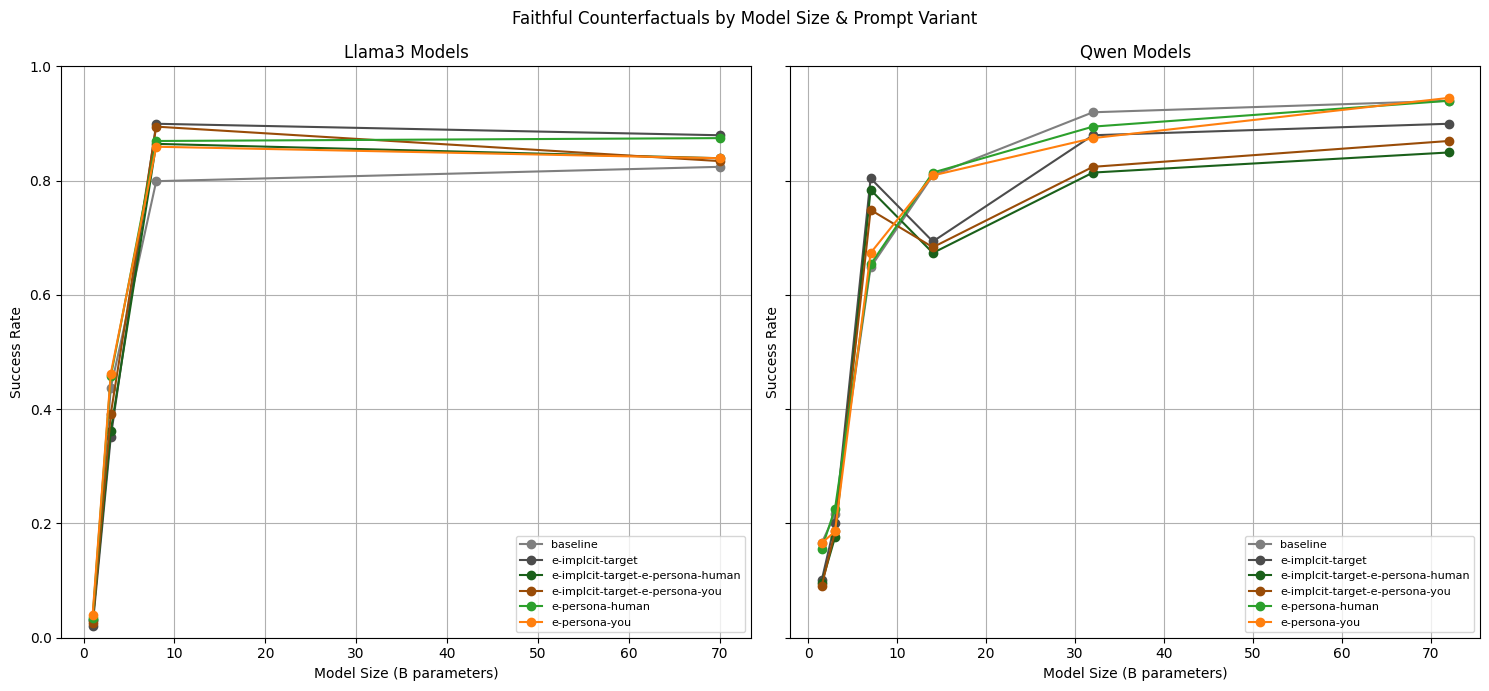

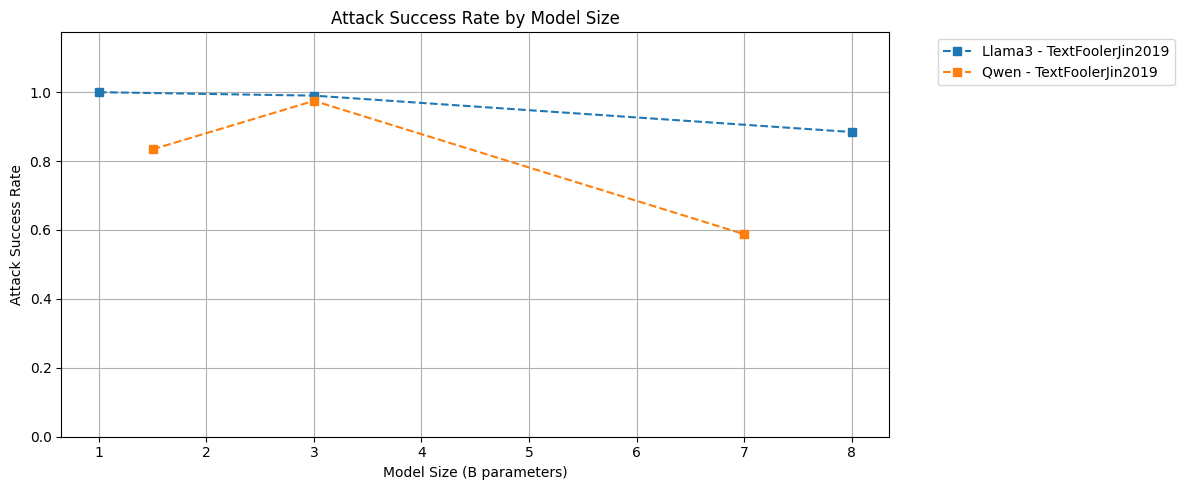

In [22]:
plot_dir = path + '/results/movie_results/plots'
plot_attack_comparison(models, attacks, plot_dir)

# Counterfactual Evaluation Metrics

Metric groups detected:
  • closeness
  • semantic_similarity
  • contradiction
  • fluency
  • diversity
  • evidence_accuracy
  • evidence_precision
  • evidence_recall
  • evidence_f1
  • crest_accuracy
  • crest_precision
  • crest_recall
  • crest_f1

🔹 Processing metric group: closeness
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/closeness_Introspection_Llama3.png


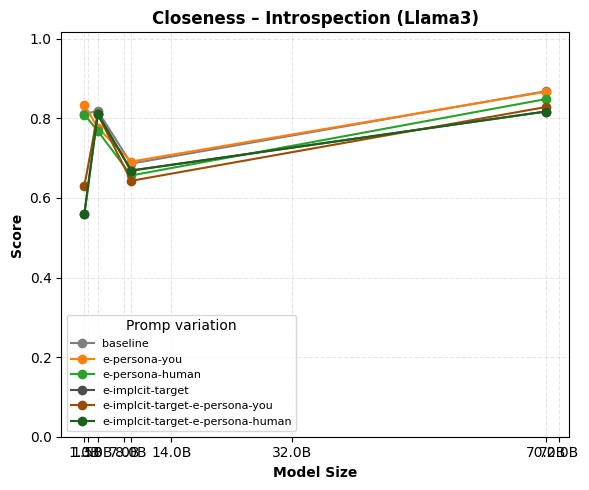

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/closeness_Introspection_Qwen.png


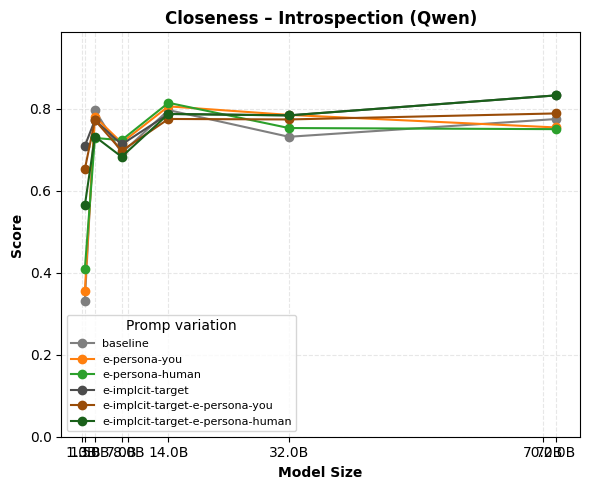

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/closeness_TextFooler.png


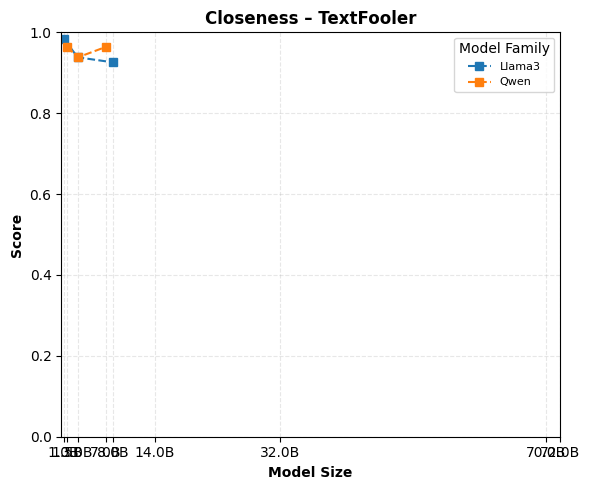


🔹 Processing metric group: semantic_similarity
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/semantic_similarity_Introspection_Llama3.png


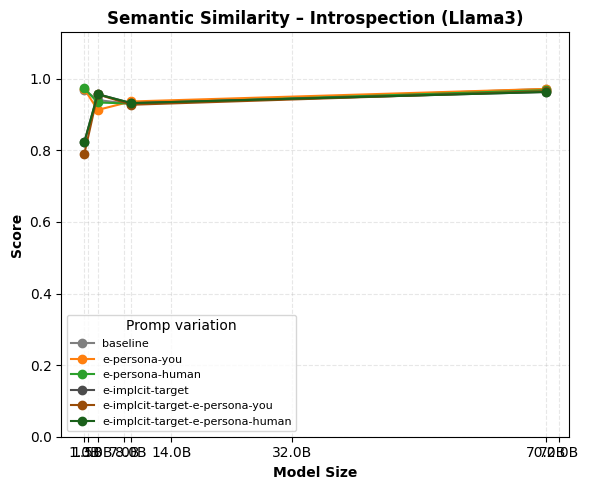

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/semantic_similarity_Introspection_Qwen.png


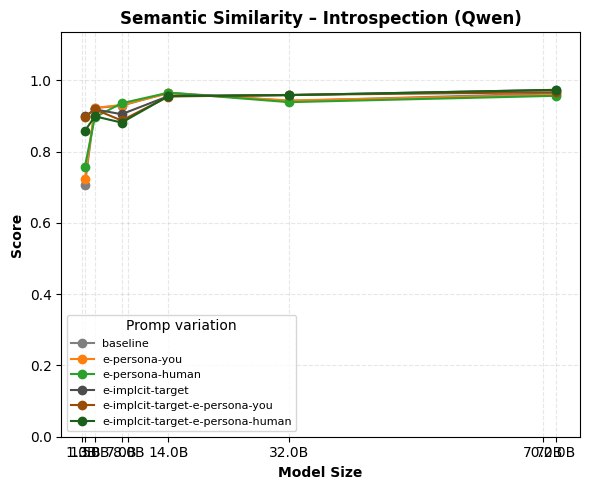

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/semantic_similarity_TextFooler.png


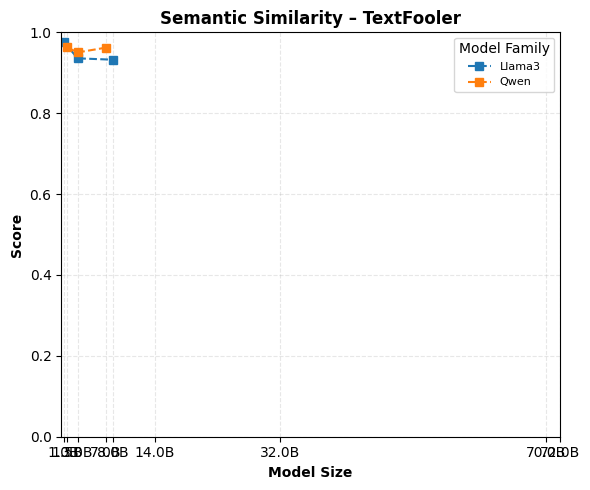


🔹 Processing metric group: contradiction
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/contradiction_Introspection_Llama3.png


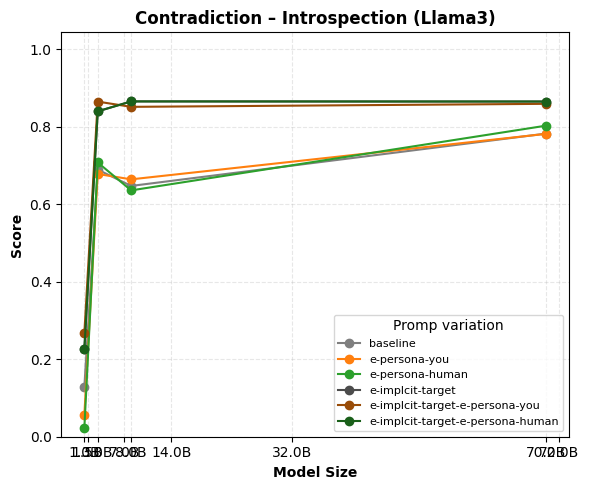

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/contradiction_Introspection_Qwen.png


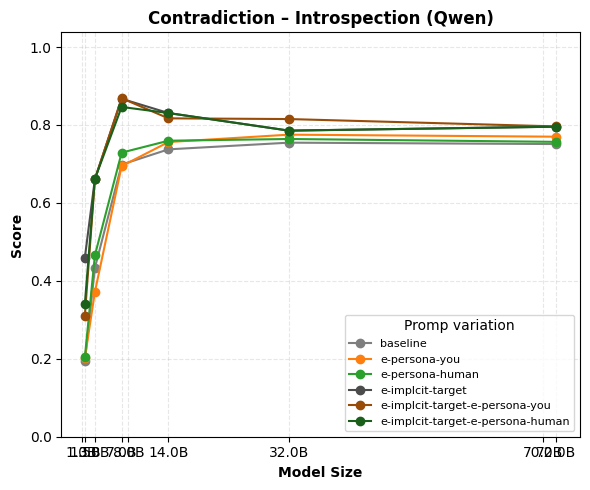

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/contradiction_TextFooler.png


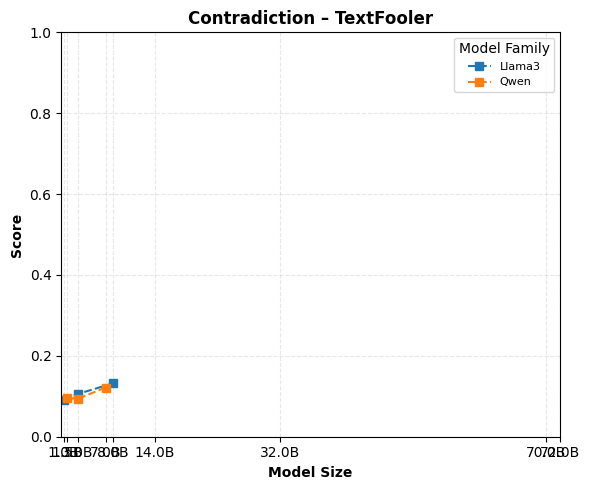


🔹 Processing metric group: fluency
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/fluency_Introspection_Llama3.png


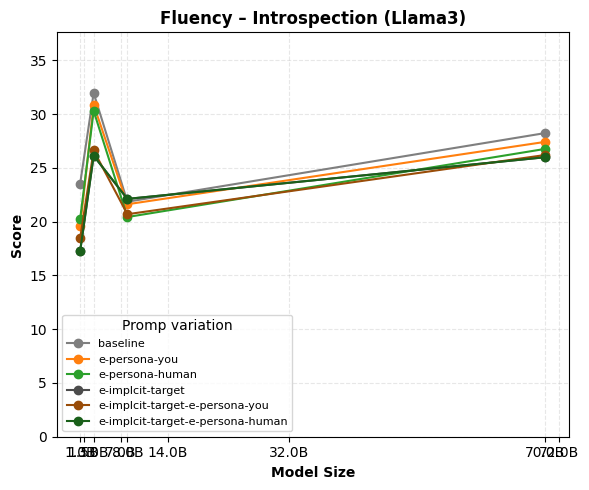

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/fluency_Introspection_Qwen.png


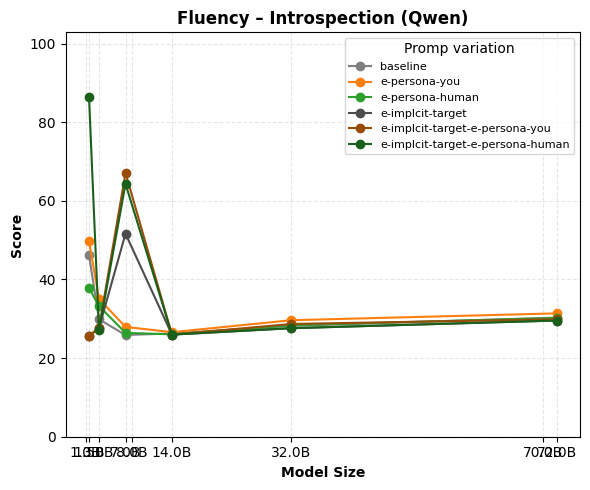

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/fluency_TextFooler.png


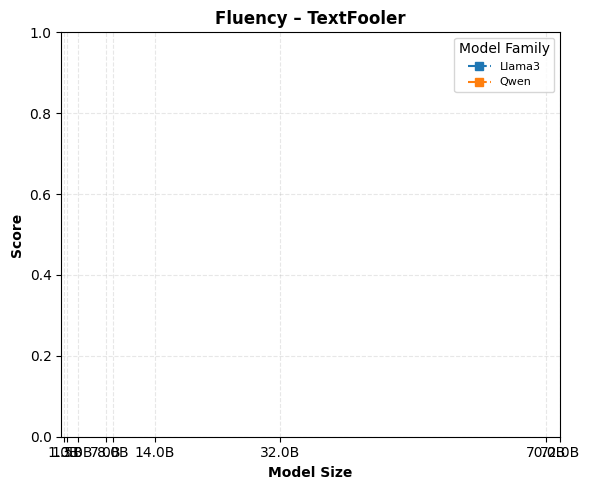


🔹 Processing metric group: diversity
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/diversity_Introspection_Llama3.png


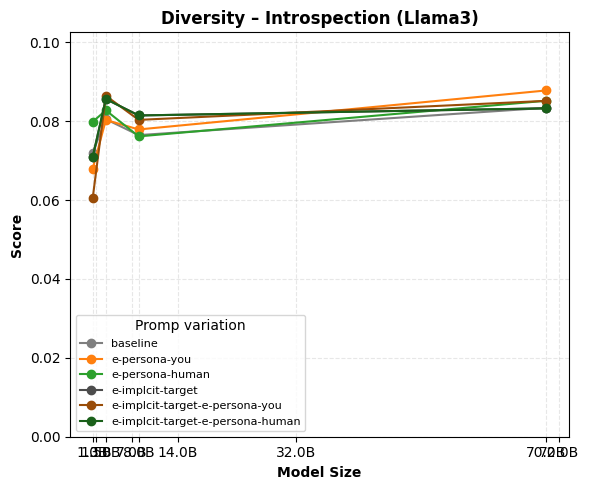

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/diversity_Introspection_Qwen.png


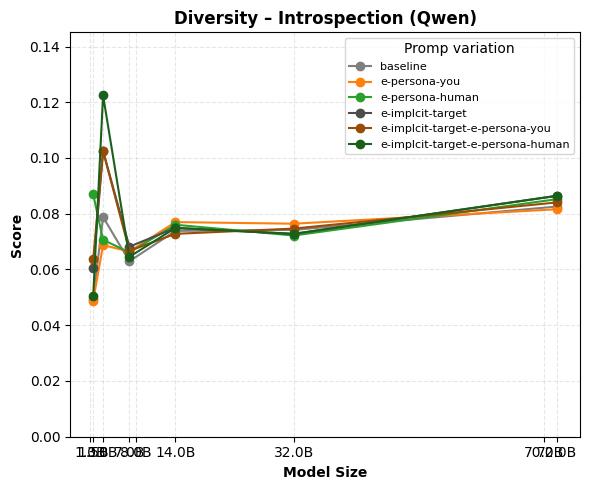

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/diversity_TextFooler.png


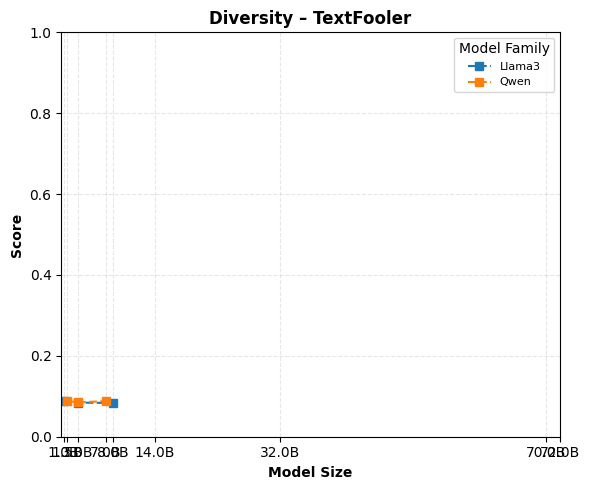


🔹 Processing metric group: evidence_accuracy
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_accuracy_Introspection_Llama3.png


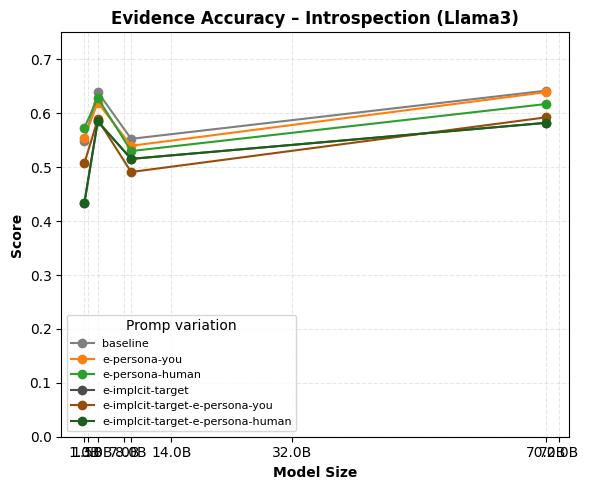

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_accuracy_Introspection_Qwen.png


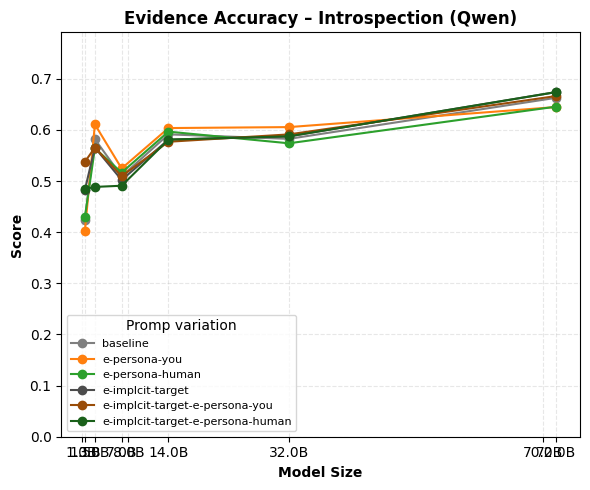

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_accuracy_TextFooler.png


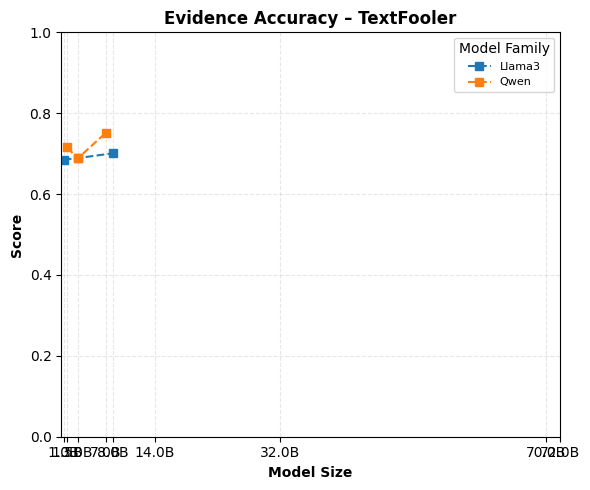


🔹 Processing metric group: evidence_precision
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_precision_Introspection_Llama3.png


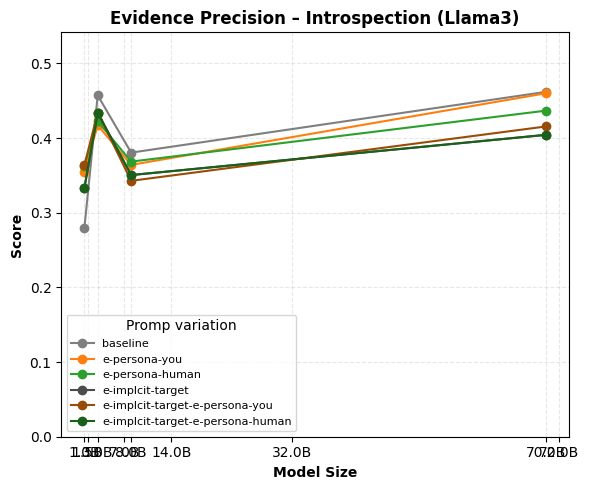

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_precision_Introspection_Qwen.png


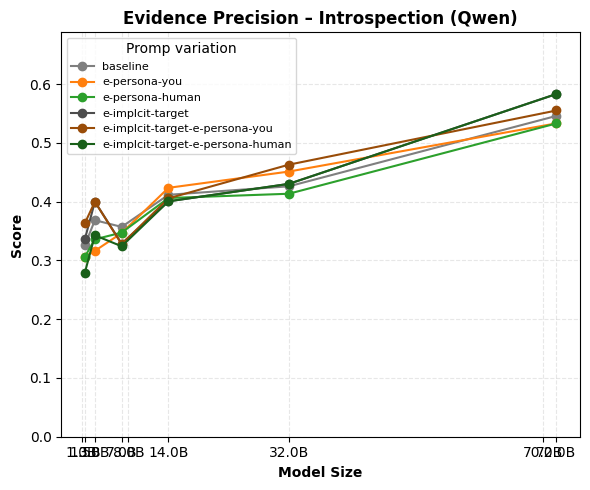

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_precision_TextFooler.png


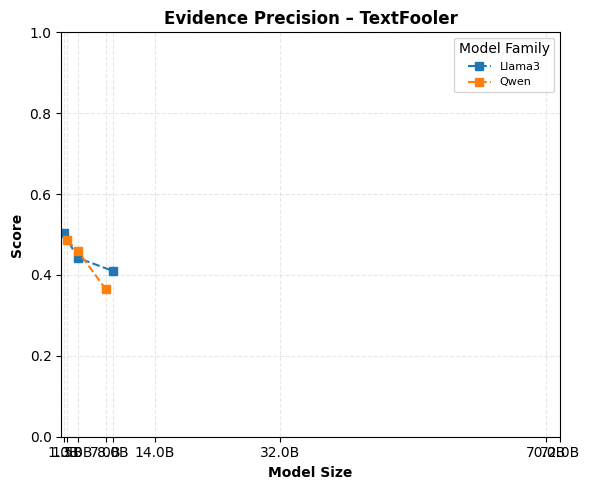


🔹 Processing metric group: evidence_recall
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_recall_Introspection_Llama3.png


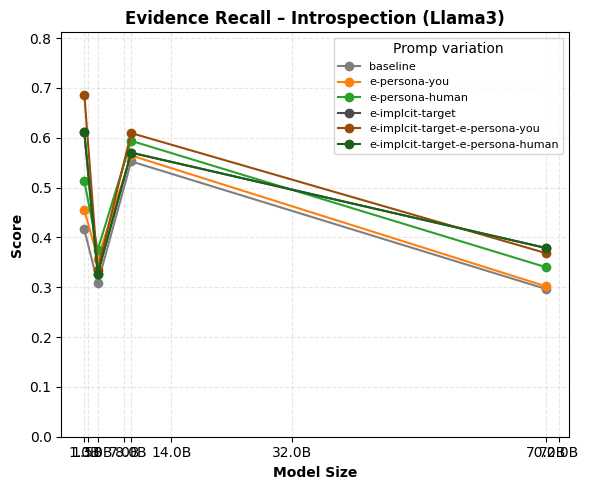

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_recall_Introspection_Qwen.png


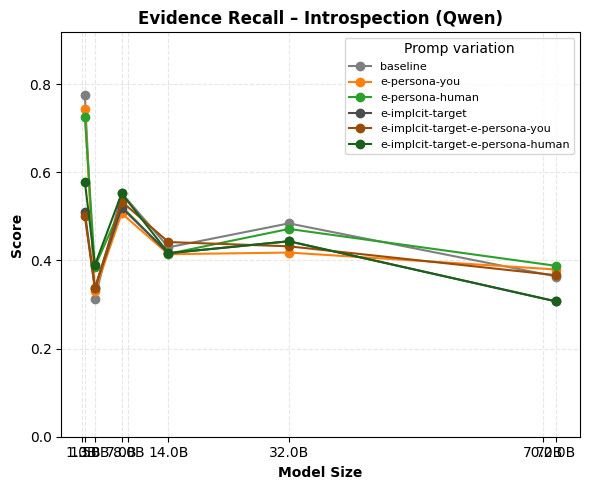

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_recall_TextFooler.png


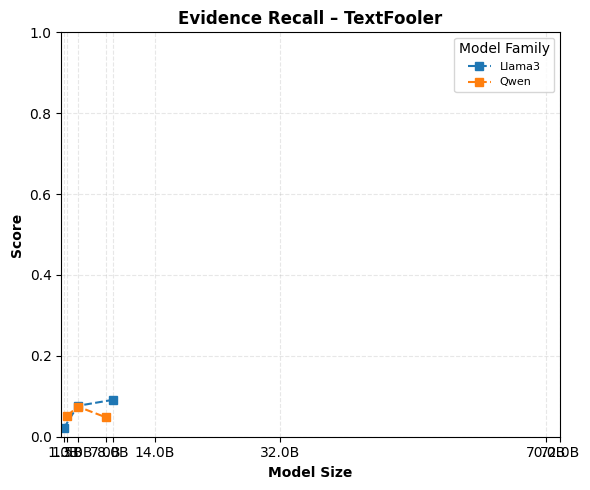


🔹 Processing metric group: evidence_f1
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_f1_Introspection_Llama3.png


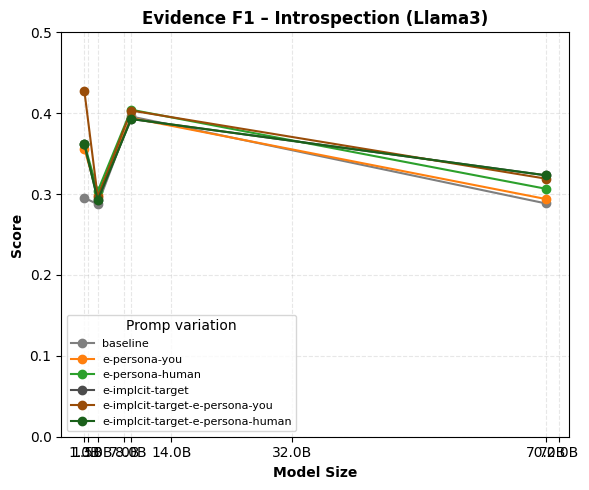

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_f1_Introspection_Qwen.png


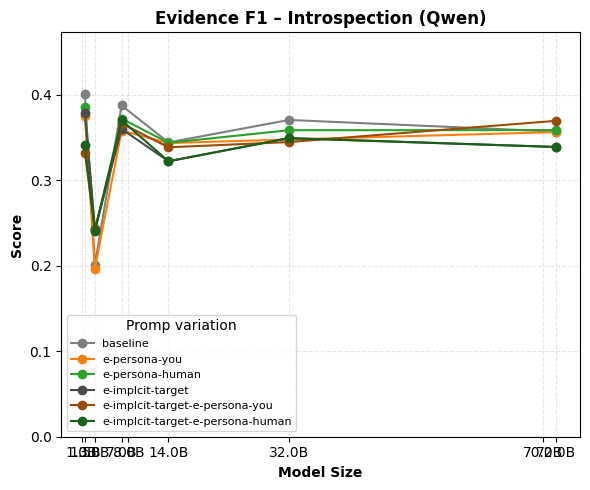

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/evidence_f1_TextFooler.png


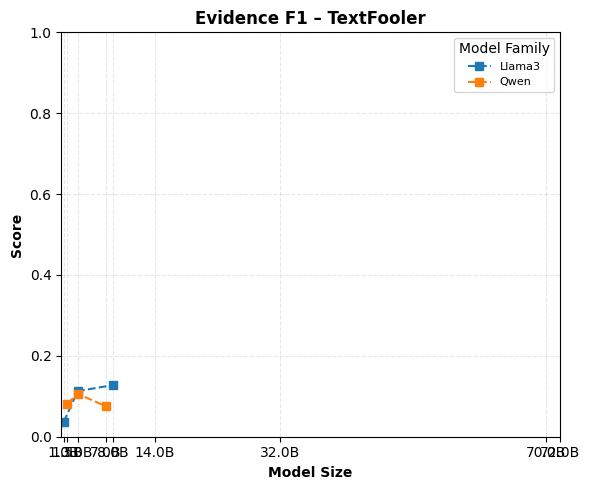


🔹 Processing metric group: crest_accuracy
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_accuracy_Introspection_Llama3.png


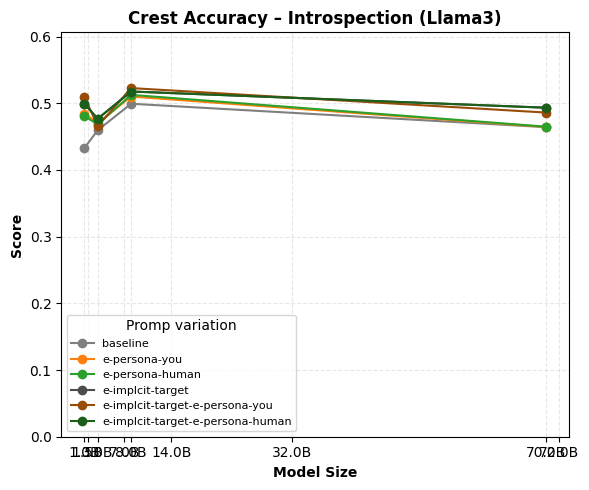

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_accuracy_Introspection_Qwen.png


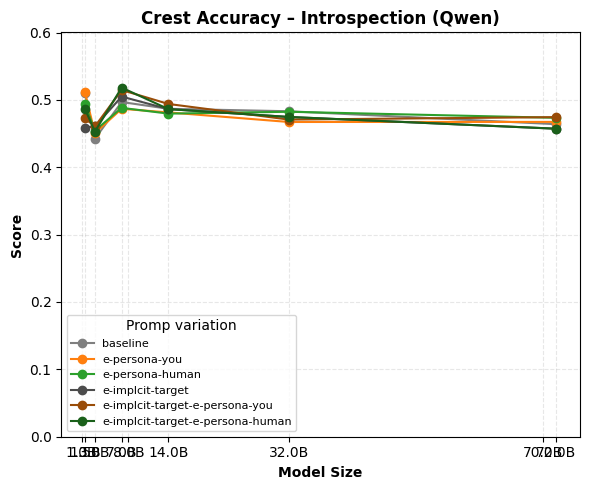

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_accuracy_TextFooler.png


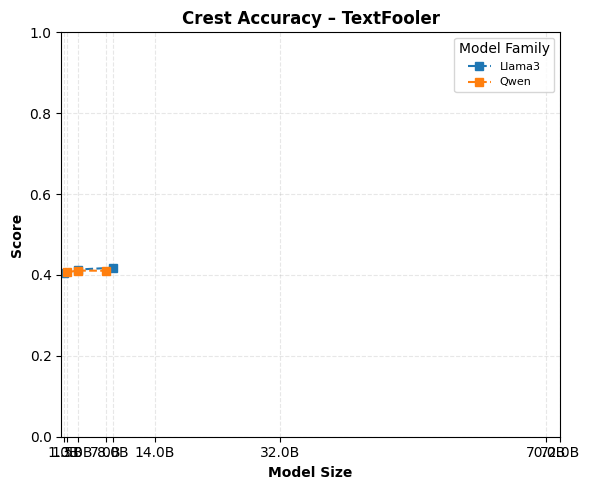


🔹 Processing metric group: crest_precision
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_precision_Introspection_Llama3.png


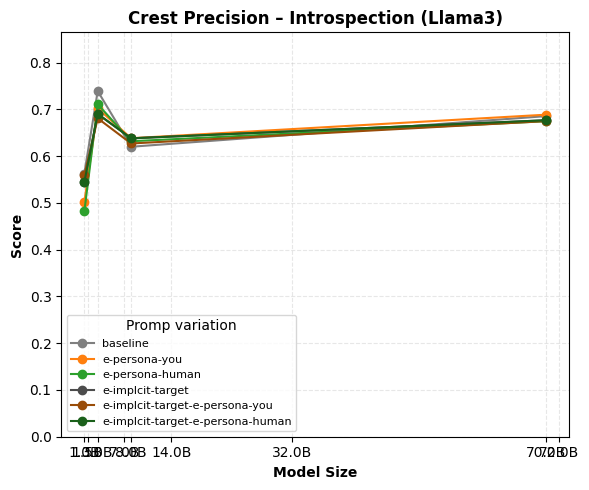

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_precision_Introspection_Qwen.png


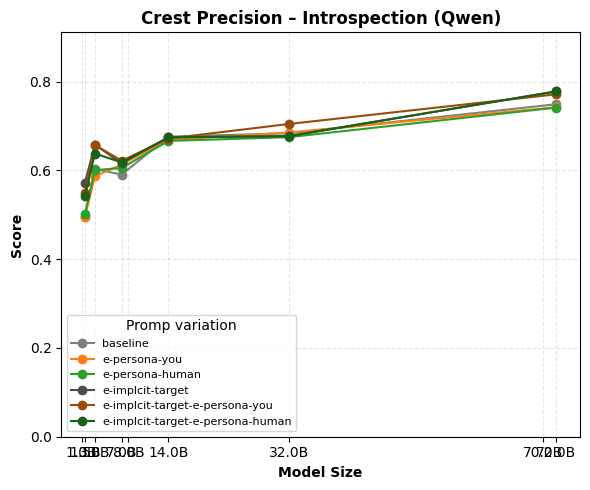

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_precision_TextFooler.png


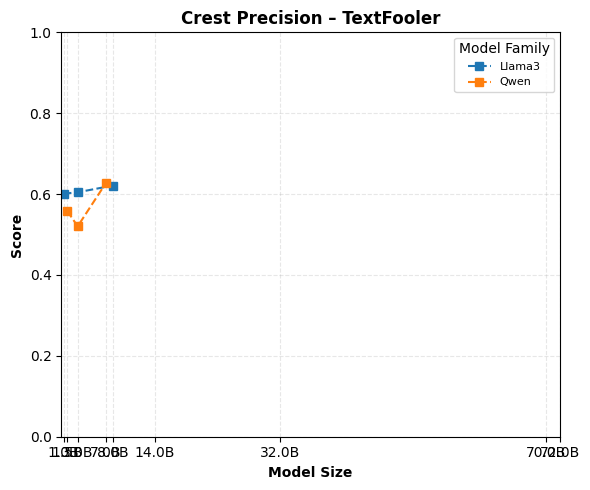


🔹 Processing metric group: crest_recall
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_recall_Introspection_Llama3.png


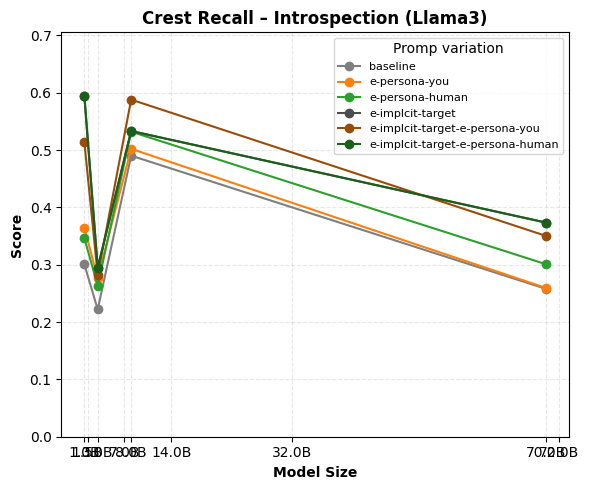

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_recall_Introspection_Qwen.png


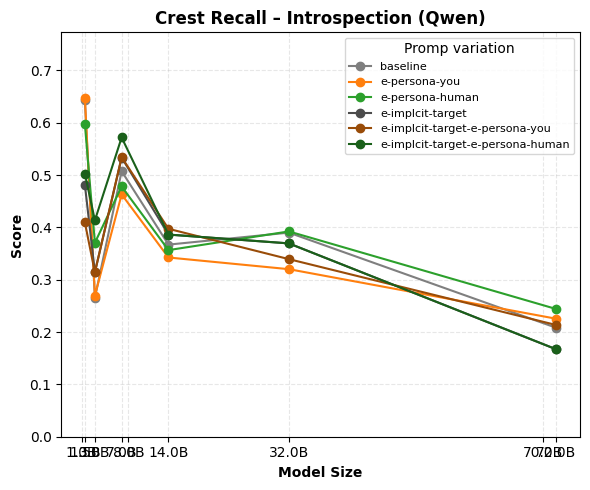

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_recall_TextFooler.png


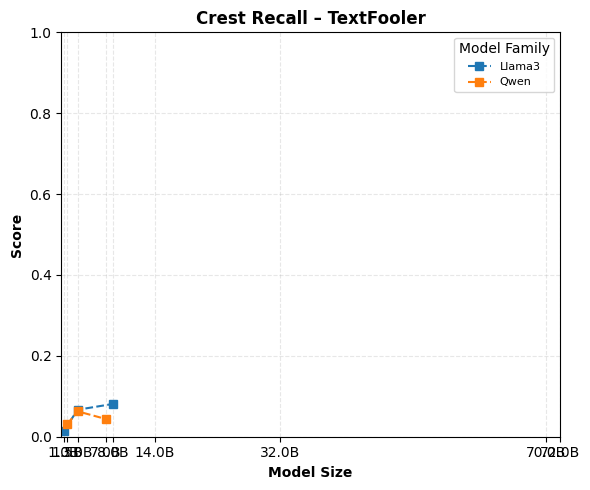


🔹 Processing metric group: crest_f1
   📊 Plotting Introspection for Llama3
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_f1_Introspection_Llama3.png


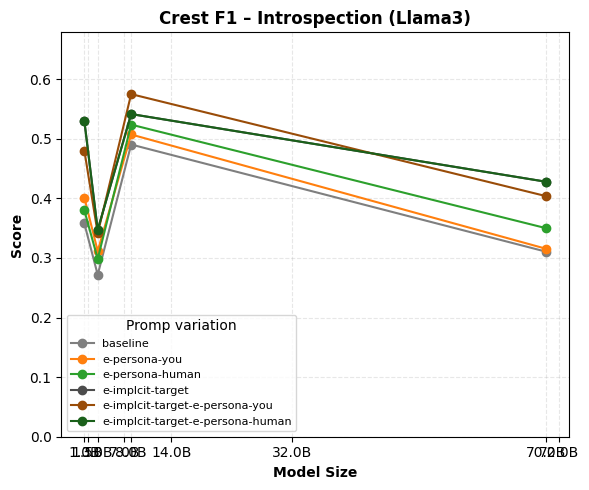

   📊 Plotting Introspection for Qwen
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_f1_Introspection_Qwen.png


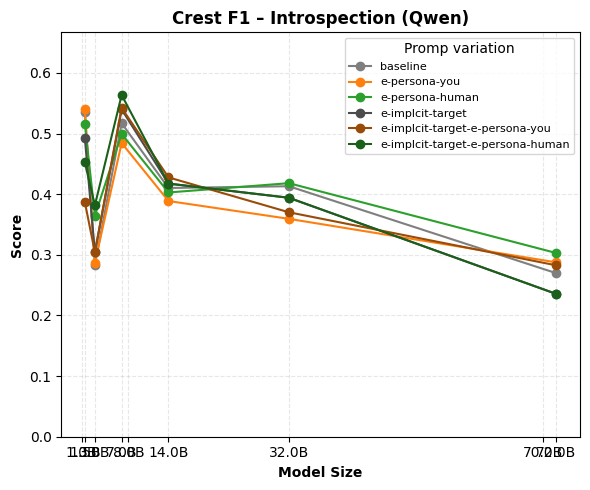

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /workspace/diploma/results/movie_results/plots/crest_f1_TextFooler.png


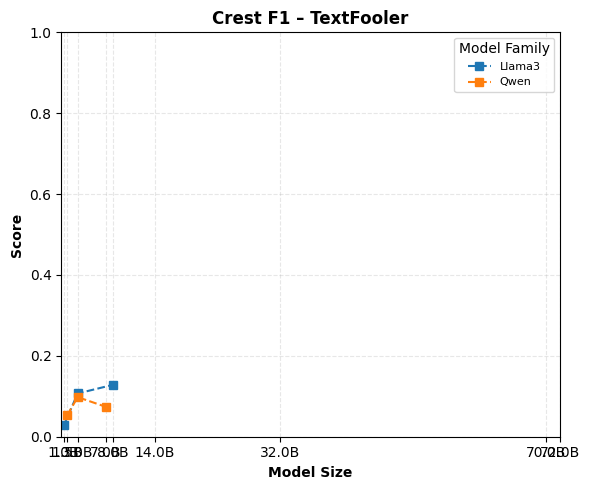

In [23]:
directory = path+'/results/movie_results/plots'
plot_size_comparison(models, results, directory, "viridis")